In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

results = pd.read_csv("../package_metadata/results_all.csv")

method_colors = {
    "kt_gaussian": "#228B22",
    "kt_matern": "#F70D1A",
    "kt_inverse_multiquadric": "#F5B027",
    "kt_sobolev": "gray",
    "iid": "#1F51FF", 
    "kt_predictions": "#895129",
    "kt_stratified": "#ff1493",
    "arfpy": "#6CC1D0",
    "influence": "#307D7E",
    "stein_thinning": "#BB8C81",
}

results_sobolev = results[results["method_total"] == "kt_sobolev"]
results_sobolev['unique_samples'].unique()

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_8904/4049717219.py:6: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")


array([1, 2, 3, 5, 4])

# Image 0

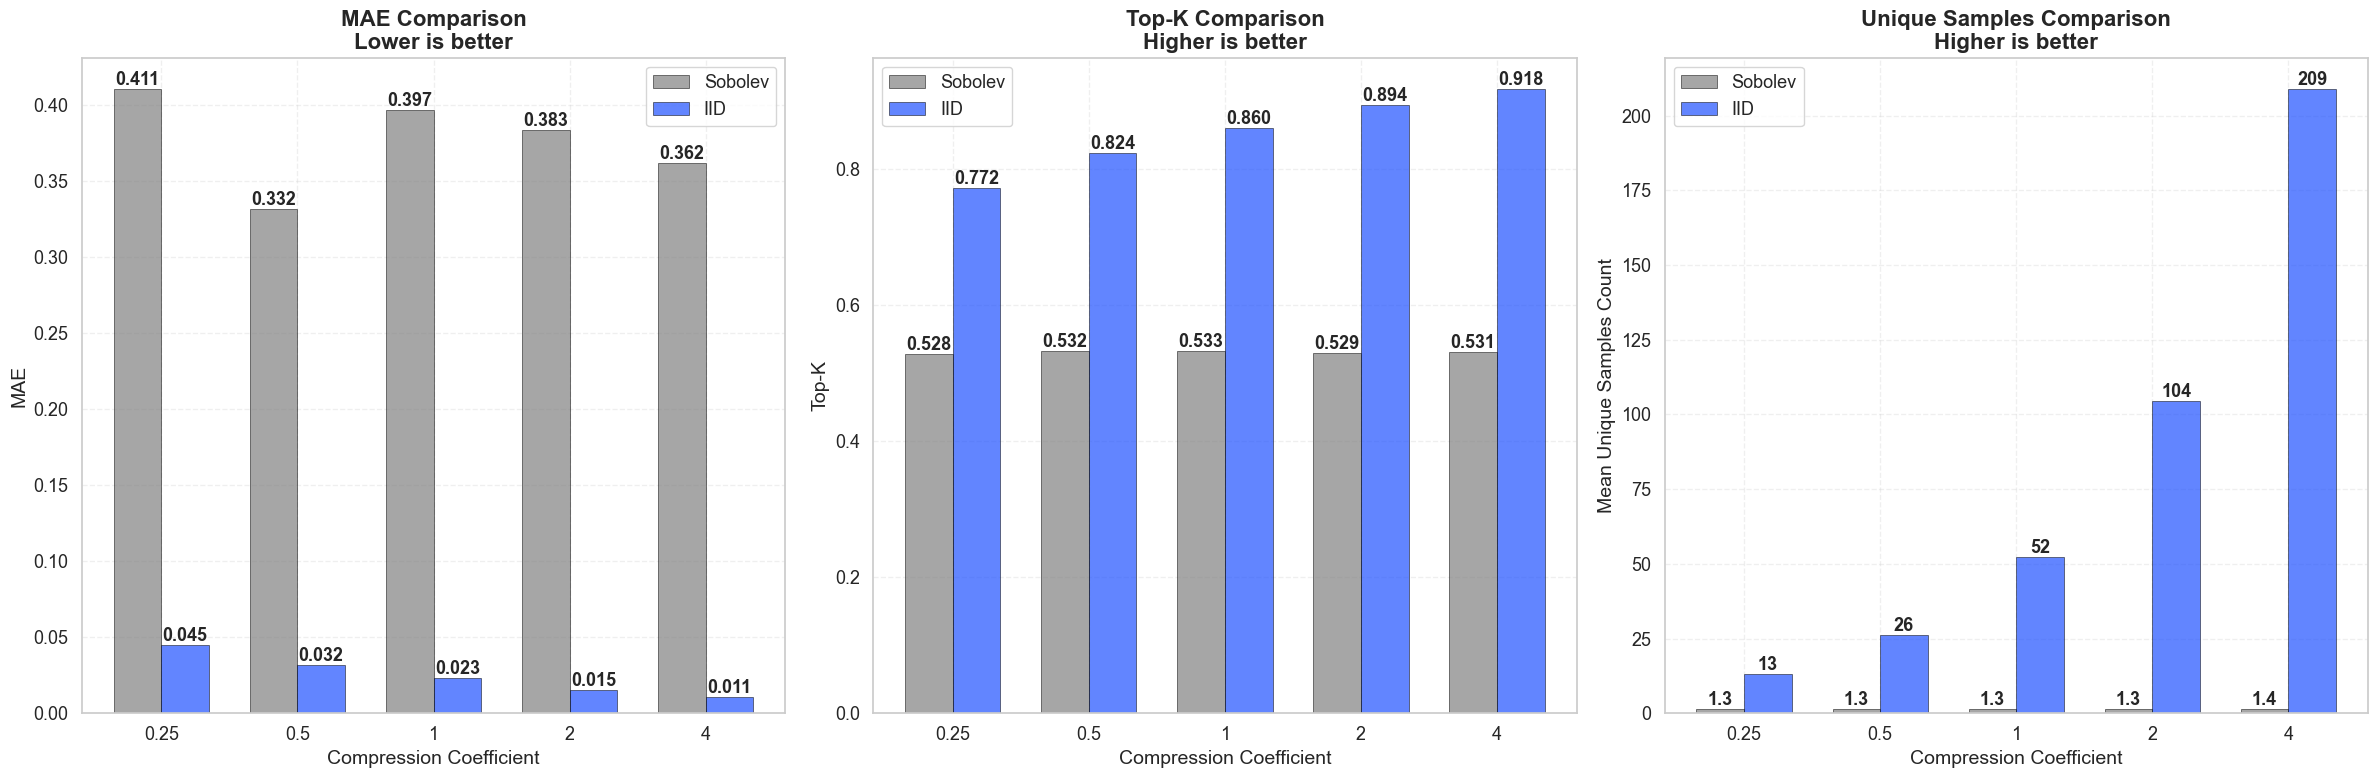

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
results_sobolev = results_aggregated[results_aggregated["method_total"] == "kt_sobolev"]
results_iid = results_aggregated[results_aggregated["method_total"] == "iid"]

data_cols = ["mae_mean", "top_k_mean", "unique_samples_mean"]
coeffs_to_keep = [0.25, 0.5, 1, 2, 4]

sobolev_agg = results_sobolev.groupby("compression_coefficient")[data_cols].mean().reset_index()
iid_agg = results_iid.groupby("compression_coefficient")[data_cols].mean().reset_index()

sobolev_agg = sobolev_agg[sobolev_agg["compression_coefficient"].isin(coeffs_to_keep)].sort_values("compression_coefficient")
iid_agg = iid_agg[iid_agg["compression_coefficient"].isin(coeffs_to_keep)].sort_values("compression_coefficient")

plt.rcParams['figure.figsize'] = (24, 8)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13

fig, axes = plt.subplots(1, 3)
fig.set_size_inches(24, 8)

x_positions = np.arange(len(coeffs_to_keep))
bar_width = 0.35

sobolev_color = 'gray'
iid_color = '#1F51FF'

mae_sobolev = sobolev_agg['mae_mean'].values
mae_iid = iid_agg['mae_mean'].values

axes[0].bar(x_positions - bar_width/2, mae_sobolev, width=bar_width, color=sobolev_color, alpha=0.7, label='Sobolev', edgecolor='black', linewidth=0.5)
axes[0].bar(x_positions + bar_width/2, mae_iid, width=bar_width, color=iid_color, alpha=0.7, label='IID', edgecolor='black', linewidth=0.5)
axes[0].set_title("MAE Comparison\nLower is better", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Compression Coefficient", fontsize=14)
axes[0].set_ylabel("MAE", fontsize=14)
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(coeffs_to_keep)
axes[0].legend(fontsize=13)
axes[0].grid(True, alpha=0.3)

for i, (val_sob, val_iid) in enumerate(zip(mae_sobolev, mae_iid)):
    axes[0].text(i - bar_width/2, val_sob, f'{val_sob:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
    axes[0].text(i + bar_width/2, val_iid, f'{val_iid:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

topk_sobolev = sobolev_agg['top_k_mean'].values
topk_iid = iid_agg['top_k_mean'].values

axes[1].bar(x_positions - bar_width/2, topk_sobolev, width=bar_width, color=sobolev_color, alpha=0.7, label='Sobolev', edgecolor='black', linewidth=0.5)
axes[1].bar(x_positions + bar_width/2, topk_iid, width=bar_width, color=iid_color, alpha=0.7, label='IID', edgecolor='black', linewidth=0.5)
axes[1].set_title("Top-K Comparison\nHigher is better", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Compression Coefficient", fontsize=14)
axes[1].set_ylabel("Top-K", fontsize=14)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(coeffs_to_keep)
axes[1].legend(fontsize=13)
axes[1].grid(True, alpha=0.3)

for i, (val_sob, val_iid) in enumerate(zip(topk_sobolev, topk_iid)):
    axes[1].text(i - bar_width/2, val_sob, f'{val_sob:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
    axes[1].text(i + bar_width/2, val_iid, f'{val_iid:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

unique_sobolev = sobolev_agg['unique_samples_mean'].values
unique_iid = iid_agg['unique_samples_mean'].values

axes[2].bar(x_positions - bar_width/2, unique_sobolev, width=bar_width, color=sobolev_color, alpha=0.7, label='Sobolev', edgecolor='black', linewidth=0.5)
axes[2].bar(x_positions + bar_width/2, unique_iid, width=bar_width, color=iid_color, alpha=0.7, label='IID', edgecolor='black', linewidth=0.5)
axes[2].set_title("Unique Samples Comparison\nHigher is better", fontsize=16, fontweight='bold')
axes[2].set_xlabel("Compression Coefficient", fontsize=14)
axes[2].set_ylabel("Mean Unique Samples Count", fontsize=14)
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels(coeffs_to_keep)
axes[2].legend(fontsize=13)
axes[2].grid(True, alpha=0.3)

for i, (val_sob, val_iid) in enumerate(zip(unique_sobolev, unique_iid)):
    axes[2].text(i - bar_width/2, val_sob, f'{val_sob:.1f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
    axes[2].text(i + bar_width/2, val_iid, f'{val_iid:.0f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

fig.savefig("Image0/sobolev_vs_iid_comparison.pdf", format='pdf', bbox_inches='tight', dpi=300)

# Image 1 - 4 kernels + iid comparison

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

methods = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric", "kt_sobolev", "iid"]

sns.set_theme(style="whitegrid")

base_dir = "Image1"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name) &
                (results['method_total'].isin(methods))
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_labels = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                for method in methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    line = ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        label=method, 
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                    
                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                ax.set_ylim(bottom=0)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            if legend_elements:
                sorted_indices = [methods.index(label) for label in legend_labels if label in methods]
                sorted_elements = [legend_elements[i] for i in sorted_indices]
                sorted_labels = [legend_labels[i] for i in sorted_indices]
                
                fig.legend(sorted_elements, sorted_labels, loc='lower center', ncol=len(methods), 
                          bbox_to_anchor=(0.5, -0.06), fontsize=36, title="METHODS", 
                          title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image1 folder.")

Process finished. All images are saved in Image1 folder.


# Image 2 - 3 kernels (- sobolev) + iid

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

methods = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric", "iid"]

sns.set_theme(style="whitegrid")

base_dir = "Image2"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name) &
                (results['method_total'].isin(methods))
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_labels = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                for method in methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    line = ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        label=method, 
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                    
                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                ax.set_ylim(bottom=0)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            if legend_elements:
                sorted_indices = [methods.index(label) for label in legend_labels if label in methods]
                sorted_elements = [legend_elements[i] for i in sorted_indices]
                sorted_labels = [legend_labels[i] for i in sorted_indices]
                
                fig.legend(sorted_elements, sorted_labels, loc='lower center', ncol=len(methods), 
                          bbox_to_anchor=(0.5, -0.06), fontsize=36, title="METHODS", 
                          title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image2 folder.")

Process finished. All images are saved in Image2 folder.


# Image 3 - 3 kernels comparison (except sobolev)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

methods = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric"]

sns.set_theme(style="whitegrid")

base_dir = "Image3"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name) &
                (results['method_total'].isin(methods))
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_labels = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                for method in methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    line = ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        label=method, 
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                    
                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                ax.set_ylim(bottom=0)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            if legend_elements:
                sorted_indices = [methods.index(label) for label in legend_labels if label in methods]
                sorted_elements = [legend_elements[i] for i in sorted_indices]
                sorted_labels = [legend_labels[i] for i in sorted_indices]
                
                fig.legend(sorted_elements, sorted_labels, loc='lower center', ncol=len(methods), 
                          bbox_to_anchor=(0.5, -0.06), fontsize=36, title="METHODS", 
                          title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image3 folder.")

Process finished. All images are saved in Image3 folder.


# Figure 4 - (kt_gaussian vs kt_predictions vs kt_stratified)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

base_methods = ["kt_gaussian", "iid", "kt_predictions"]
classification_only_methods = ["kt_stratified"]

sns.set_theme(style="whitegrid")

base_dir = "Image4"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name)
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_handles = []
            legend_labels = []
            
            all_methods_for_legend = base_methods.copy()
            
            has_classification_datasets = len(classification_list) > 0
            
            if has_classification_datasets and "kt_stratified" not in all_methods_for_legend:
                all_methods_for_legend.append("kt_stratified")
            
            for method in all_methods_for_legend:
                color = method_colors.get(method, "black")
                line = plt.Line2D([0], [0], 
                                color=color, 
                                marker='o',
                                markersize=12,
                                linewidth=4.5,
                                markeredgewidth=3,
                                markeredgecolor=color,
                                label=method)
                legend_handles.append(line)
                legend_labels.append(method)

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                if is_regression:
                    dataset_methods = base_methods
                else:
                    dataset_methods = base_methods + classification_only_methods

                for method in dataset_methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                
                y_min = grouped['mean'].min()
                y_max = grouped['mean'].max()
                if y_min >= 0:
                    ax.set_ylim(bottom=0)
                else:
                    ax.set_ylim(bottom=y_min * 1.05)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            if legend_handles:
                fig.legend(legend_handles, legend_labels, 
                          loc='lower center', 
                          ncol=min(len(legend_labels), 4),
                          bbox_to_anchor=(0.5, -0.06), 
                          fontsize=36, 
                          title="METHODS", 
                          title_fontsize=40, 
                          frameon=True, 
                          shadow=True, 
                          borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image4 folder.")

Process finished. All images are saved in Image4 folder.


# Image 5 - different baselines

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ['nn', 'xgboost']

all_legend_methods = ["stein_thinning", "arfpy", "iid", "kt_matern", "influence"]

sns.set_theme(style="whitegrid")

base_dir = "Image5"
os.makedirs(base_dir, exist_ok=True)

for model_name in all_models:
    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for explainer_total in all_explainers:
        for metric in all_metrics:

            mask = (
                (results['explainer_total'] == explainer_total) &
                (results['model_name'] == model_name)
            )
            filtered_results = results[mask]
            
            if filtered_results.empty:
                continue

            regression_list = []
            classification_list = []
            
            unique_datasets = sorted(filtered_results['dataset_name'].unique())
            for dataset in unique_datasets:
                ds_data = filtered_results[filtered_results['dataset_name'] == dataset]
                if not ds_data.empty and ds_data[metric].notna().any():
                    task_type = ds_data['task'].iloc[0] if 'task' in ds_data.columns else 'unknown'
                    if task_type == 'regression':
                        regression_list.append(dataset)
                    else:
                        classification_list.append(dataset)

            available_datasets = regression_list + classification_list
            if not available_datasets:
                continue

            n_cols = 4
            n_rows = ceil(len(available_datasets) / n_cols)

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 8 * n_rows))
            axes = np.atleast_1d(axes).flatten()

            legend_elements = []
            legend_labels = []

            for idx, dataset_name in enumerate(available_datasets):
                ax = axes[idx]
                is_regression = dataset_name in regression_list
                
                ax.set_facecolor('#f2f8ff' if is_regression else '#fffafa')
                
                data_plot = filtered_results[filtered_results['dataset_name'] == dataset_name]
                grouped = data_plot.groupby(['size', 'method_total'])[metric].agg(['mean', 'std', 'count']).reset_index()
                grouped['std_error'] = grouped['std'] / np.sqrt(grouped['count'])

                for method in all_legend_methods:
                    method_data = grouped[grouped['method_total'] == method]
                    if method_data.empty:
                        continue
                    
                    color = method_colors.get(method, "black")
                    
                    line = ax.errorbar(
                        x=method_data['size'], 
                        y=method_data['mean'], 
                        yerr=method_data['std_error'],
                        label=method, 
                        marker='o', 
                        capsize=13,
                        markeredgewidth=3, 
                        linewidth=4.5,      
                        markersize=12,      
                        alpha=0.9,
                        color=color,
                        markeredgecolor=color,
                        elinewidth=2.5 
                    )
                    
                    if idx == 0 and method not in legend_labels:
                        legend_elements.append(line)
                        legend_labels.append(method)
                
                ax.set_xscale('log')
                ax.set_title(f'{dataset_name}', fontsize=40, fontweight='bold', pad=30)
                ax.set_xlabel('Sample Size', fontsize=36, fontweight='bold')
                ax.set_ylabel(f'{metric.upper()}', fontsize=36, fontweight='bold')
                
                y_min = grouped['mean'].min()
                y_max = grouped['mean'].max()
                if y_min >= 0:
                    ax.set_ylim(bottom=0)
                else:
                    ax.set_ylim(bottom=y_min * 1.05)
                
                ax.tick_params(axis='both', which='major', labelsize=32) 
                ax.tick_params(axis='both', which='minor', labelsize=24)
                
                ax.grid(True, which="both", alpha=0.6, linestyle='--', color='gray')
                ax.xaxis.set_major_formatter(plt.ScalarFormatter())
                ax.ticklabel_format(style='sci', axis='y', scilimits=(-2,2))
                ax.yaxis.get_offset_text().set_fontsize(30)

            for i in range(len(available_datasets), len(axes)):
                axes[i].set_visible(False)

            from matplotlib.lines import Line2D
            
            sorted_elements = []
            sorted_labels = []
            
            for method in all_legend_methods:
                if method in legend_labels:
                    idx = legend_labels.index(method)
                    sorted_elements.append(legend_elements[idx])
                    sorted_labels.append(legend_labels[idx])
                else:
                    color = method_colors.get(method, "black")
                    proxy_line = Line2D([0], [0], color=color, linewidth=4.5, marker='o', 
                                       markersize=12, markeredgewidth=3, alpha=0.9)
                    sorted_elements.append(proxy_line)
                    sorted_labels.append(method)

            for i, label in enumerate(legend_labels):
                if label not in sorted_labels:
                    sorted_elements.append(legend_elements[i])
                    sorted_labels.append(label)
            
            fig.legend(sorted_elements, sorted_labels, loc='lower center', 
                      ncol=min(len(sorted_labels), 4),
                      bbox_to_anchor=(0.5, -0.06), fontsize=36, title="METHODS", 
                      title_fontsize=40, frameon=True, shadow=True, borderpad=1.5)

            plt.tight_layout(rect=[0, 0, 1, 1])
            plt.subplots_adjust(hspace=0.8, wspace=0.45)

            file_name = f"{explainer_total}_{metric}.png"
            plt.savefig(os.path.join(model_dir, file_name), bbox_inches='tight', dpi=100)
            plt.close(fig) 

print("Process finished. All images are saved in Image5 folder.")

Process finished. All images are saved in Image5 folder.


# Image 12 - custom methods

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from math import ceil
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")

all_explainers = ["expected_gradients", "shap_kernel", "sage_permutation", "shapiq_kernel"]
all_metrics = ["explanation_time", "mae", "top_k", "mmd", "compression_time"]
all_models = ["nn", "xgboost"]

base_methods = ["kt_gaussian", "iid", "kt_predictions"]
classification_only_methods = ["kt_stratified"]

base_dir = "Image12"
os.makedirs(base_dir, exist_ok=True)

model_styles = {
    "nn": "-",
    "xgboost": "--",
}

for explainer_total in all_explainers:
    for metric in all_metrics:

        filtered = results[results["explainer_total"] == explainer_total]
        if filtered.empty:
            continue

        datasets = sorted(filtered["dataset_name"].unique())
        if not datasets:
            continue

        n_cols = 4
        n_rows = ceil(len(datasets) / n_cols)

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(6.5 * n_cols, 4.8 * n_rows),
            sharex=False,
            sharey=False,
        )
        axes = np.atleast_1d(axes).flatten()

        for idx, dataset_name in enumerate(datasets):
            ax = axes[idx]

            ds_data = filtered[filtered["dataset_name"] == dataset_name]
            task_type = ds_data["task"].iloc[0]

            # Subtle background for task type
            ax.set_facecolor("#f2f8ff" if task_type == "regression" else "#fff5f5")

            grouped = (
                ds_data
                .groupby(["size", "method_total", "model_name"])[metric]
                .agg(["mean", "std", "count"])
                .reset_index()
            )
            grouped["stderr"] = grouped["std"] / np.sqrt(grouped["count"])

            methods_here = base_methods.copy()
            if task_type == "classification":
                methods_here += classification_only_methods

            for method in methods_here:
                for model in all_models:
                    sub = grouped[
                        (grouped["method_total"] == method) &
                        (grouped["model_name"] == model)
                    ]
                    if sub.empty:
                        continue

                    ax.errorbar(
                        sub["size"],
                        sub["mean"],
                        yerr=sub["stderr"],
                        color=method_colors.get(method, "black"),
                        linestyle=model_styles[model],
                        marker="o",
                        markersize=6,
                        linewidth=2.2,
                        capsize=4,
                        alpha=0.9,
                    )

            ax.set_xscale("log")
            ax.set_title(dataset_name, fontsize=14, pad=8)
            ax.set_xlabel("Sample size", fontsize=11)
            ax.set_ylabel(metric.replace("_", " ").upper(), fontsize=11)

            ymin = grouped["mean"].min()
            if ymin >= 0:
                ax.set_ylim(bottom=0)

            ax.tick_params(axis="both", labelsize=10)
            ax.grid(True, which="both", linestyle="--", alpha=0.4)

        # Hide unused axes
        for i in range(len(datasets), len(axes)):
            axes[i].set_visible(False)

        # ---------- LEGEND ----------
        method_handles = [
            Line2D([0], [0], color=method_colors[m], lw=3, label=m)
            for m in base_methods + classification_only_methods
            if m in filtered["method_total"].unique()
        ]

        model_handles = [
            Line2D([0], [0], color="black", lw=3, linestyle=model_styles[m], label=m.upper())
            for m in all_models
        ]

        fig.legend(
            handles=method_handles + model_handles,
            loc="lower center",
            ncol=4,
            fontsize=11,
            frameon=True,
            title="Compression method (color) / Model (line style)",
            title_fontsize=12,
            bbox_to_anchor=(0.5, -0.02),
        )

        fig.suptitle(
            f"{explainer_total.replace('_', ' ').title()} — {metric.replace('_', ' ').upper()}",
            fontsize=18,
            y=1.02,
        )

        plt.tight_layout()
        plt.savefig(
            os.path.join(base_dir, f"{explainer_total}_{metric}.png"),
            dpi=200,
            bbox_inches="tight",
        )
        plt.close(fig)

print("Done. Combined NN + XGB plots saved to Image12.")

Done. Combined NN + XGB plots saved to Image12.
